# AI Career Project Strategist – Multi-Agent LangGraph Workflow

## Scenario Description

This project implements a multi-agent AI workflow using LangGraph and LangChain.

The system helps users choose, evaluate, and improve an AI portfolio project based on their career goals, current skills, available time, and target role.

The workflow uses multiple specialized AI agents, custom tools, graph state, conversation memory, and a Human-in-the-Loop review process before generating the final project recommendation.

## Main Goal

The goal is to demonstrate how a stateful multi-agent system can solve a complex, multi-step task by coordinating different agents with separate responsibilities.

## Agents

The workflow includes four workflow agents/nodes:

1. **Career Analyst Agent** – analyzes the user's goal, target role, skills, and project direction.
2. **Project Architect Agent** – creates a concrete AI project plan.
3. **Reviewer Agent** – checks whether the project plan satisfies the assignment requirements and suggests improvements.
4. **Final Response Agent** – produces the final approved project recommendation after the Human-in-the-Loop review.

## Tools

The system uses custom Python tools for:

- skill matching;
- project complexity estimation;
- assignment requirement compliance checking.

## Human-in-the-Loop

Before the final answer is generated, the workflow pauses and asks for human approval or revision feedback.

Based on the human feedback, the graph resumes execution and the Final Response Agent produces the final project recommendation.

## Install Required Dependencies

This cell installs the required Python libraries for building the multi-agent workflow.

The project uses:

- `langchain` for LLM and tool integration;
- `langchain-openai` for connecting to OpenAI models;
- `langgraph` for building the stateful multi-agent workflow;
- `typing_extensions` for type definitions used in the workflow state.

In [20]:
!pip install -q langchain langchain-openai langgraph typing_extensions

## API Key and LangSmith Setup

This cell loads the OpenAI API key and optionally enables LangSmith tracing.

The OpenAI API key is required for the notebook to run.

The LangSmith API key is optional, but when provided, it enables tracing and observability for the LangGraph workflow. This allows the user to inspect how the agents, tools, prompts, and model calls interact during execution.

When tracing is enabled, the workflow runs can be inspected in the LangSmith dashboard under the project name `AI Career Project Strategist`.

This helps demonstrate the internal agent interactions at a lower level, including model calls, prompts, tool usage, latency, and possible errors.

The API keys are not written directly in the code. They are loaded from Google Colab Secrets, following the security requirement that keys must be stored in environment variables or secrets.

**Important:** This notebook requires a valid OpenAI API key and an API account with available credit or active billing. Otherwise, the API requests will fail and the project will not run correctly.

In [21]:
import os
from google.colab import userdata

# Required OpenAI API key
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# Optional LangSmith tracing setup
langsmith_api_key = userdata.get("LANGSMITH_API_KEY")

if os.environ["OPENAI_API_KEY"]:
    print("OPENAI_API_KEY loaded successfully.")
else:
    print("OPENAI_API_KEY was not found. Check Colab Secrets.")

if langsmith_api_key:
    os.environ["LANGSMITH_API_KEY"] = langsmith_api_key
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = "AI Career Project Strategist"
    print("LangSmith tracing enabled.")
else:
    os.environ["LANGSMITH_TRACING"] = "false"
    print("LangSmith tracing not enabled. Add LANGSMITH_API_KEY to Colab Secrets to enable tracing.")

OPENAI_API_KEY loaded successfully.
LangSmith tracing enabled.


## Import Required Modules

This cell imports the required Python, LangChain, and LangGraph components.

The imports include:

- message classes for communication with the LLM;
- the `tool` decorator for custom tools;
- `StateGraph` for building the workflow;
- `MemorySaver` for graph memory;
- `interrupt` and `Command` for the Human-in-the-Loop process.

In [22]:
from typing import TypedDict, List
from typing_extensions import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

print("Imports loaded successfully.")

Imports loaded successfully.


## Define Workflow State

This cell defines the shared state of the LangGraph workflow.

The `WorkflowState` stores the progress of the workflow as data moves between the agents.

It includes the original user request, agent outputs, human feedback, final output, and message history.

In [23]:
class WorkflowState(TypedDict):
    user_request: str
    career_analysis: str
    project_plan: str
    review_feedback: str
    human_feedback: str
    final_output: str
    messages: List

print("WorkflowState defined successfully.")

WorkflowState defined successfully.


## Define Custom Tools

This cell defines the custom LangChain tools used by the agents.

The workflow uses three tools:

1. `skill_match_tool` – evaluates how well the user's skills match the target role.
2. `project_complexity_tool` – estimates project complexity, risk level, and feasibility.
3. `assignment_compliance_tool` – checks whether the project plan covers the assignment requirements.

These tools help the agents make more structured and practical decisions.

In [24]:
@tool
def skill_match_tool(target_role: str, skills: str) -> str:
    """
    Evaluates how well the user's current skills match the target role.
    """
    role_keywords = target_role.lower()
    skills_lower = skills.lower()

    score = 50
    matched_skills = []
    missing_skills = []

    if "python" in skills_lower:
        score += 10
        matched_skills.append("Python")
    else:
        missing_skills.append("Python")

    if "langchain" in skills_lower:
        score += 15
        matched_skills.append("LangChain")
    else:
        missing_skills.append("LangChain")

    if "langgraph" in skills_lower:
        score += 15
        matched_skills.append("LangGraph")
    else:
        missing_skills.append("LangGraph")

    if "automation" in skills_lower or "n8n" in skills_lower:
        score += 10
        matched_skills.append("Automation / n8n")
    else:
        missing_skills.append("Automation / n8n")

    if "ai" in skills_lower:
        score += 10
        matched_skills.append("AI")
    else:
        missing_skills.append("AI")

    score = min(score, 100)

    return f"""
Skill match analysis for target role: {target_role}

Match score: {score}%
Matched skills: {matched_skills}
Missing or unclear skills: {missing_skills}
"""


@tool
def project_complexity_tool(project_idea: str, available_days: int) -> str:
    """
    Estimates the complexity, risk level, and feasibility of a project idea.
    """
    idea = project_idea.lower()

    complexity = "Medium"
    risk = "Manageable"
    recommendation = "The project is suitable for a student-level final assignment."

    if "multi-agent" in idea or "langgraph" in idea:
        complexity = "Medium-High"

    if available_days < 5:
        risk = "High"
        recommendation = "The scope should be reduced significantly."
    elif available_days <= 10:
        risk = "Manageable"
        recommendation = "The project is realistic if the scope stays focused."
    else:
        risk = "Low"
        recommendation = "There is enough time to add polish and documentation."

    return f"""
Project complexity estimate:

Complexity: {complexity}
Risk level: {risk}
Available time: {available_days} days
Recommendation: {recommendation}
"""


@tool
def assignment_compliance_tool(project_plan: str) -> str:
    """
    Checks whether the project plan covers the assignment requirements.
    """
    required_items = [
        "LangGraph",
        "LangChain",
        "multi-agent",
        "tools",
        "memory",
        "Human-in-the-Loop",
        "execute_workflow",
        "test cases"
    ]

    covered = []
    missing = []

    plan_lower = project_plan.lower()

    for item in required_items:
        if item.lower() in plan_lower:
            covered.append(item)
        else:
            missing.append(item)

    return f"""
Assignment compliance check:

Covered requirements: {covered}
Missing or unclear requirements: {missing}
"""

print("Custom tools defined successfully.")

Custom tools defined successfully.


## Initialize the Language Model

This cell initializes the OpenAI chat model used by the agents.

The agents use this model to analyze the user request, create the project plan, review the result, and generate the final recommendation.

In [25]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.3
)

print("LLM initialized successfully.")

LLM initialized successfully.


## Career Analyst Agent

This cell defines the Career Analyst Agent.

The agent analyzes the user's career goal, target role, existing skills, and project direction.

It also uses the `skill_match_tool` to evaluate how well the user's current skills match a Junior AI Automation role.

In [26]:
def career_analyst_agent(state: WorkflowState) -> WorkflowState:
    system_prompt = """
    You are a Career Analyst Agent.

    Your responsibility is to analyze the user's career goal, target role,
    current skills, available time, and project needs.

    IMPORTANT:
    The final project topic is already fixed:
    "AI Career Project Strategist"

    This means the system itself is the project:
    a multi-agent assistant that helps users choose, evaluate, improve,
    and finalize an AI portfolio project based on their career goals,
    skills, available time, and target role.

    Do NOT recommend a different project topic.
    Do NOT suggest chatbot projects, predictive maintenance, dashboards,
    travel planners, scraping systems, or customer support systems as the final project.

    Your analysis should explain why "AI Career Project Strategist" is a good fit
    for the user's target role.
    """

    skill_tool_result = skill_match_tool.invoke({
        "target_role": "Junior AI Automation Role",
        "skills": "Python, LangChain, LangGraph, AI, automation, n8n, SoftUni projects"
    })

    user_prompt = f"""
    User request:
    {state['user_request']}

    Tool result:
    {skill_tool_result}

    Analyze the request and provide:
    - target role or goal
    - relevant existing skills
    - missing or unclear skills
    - why AI Career Project Strategist is the best project direction
    - how this project supports a Junior AI Automation career path

    Keep the analysis focused only on AI Career Project Strategist.
    """

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    state["career_analysis"] = response.content
    state["messages"].append(AIMessage(content=response.content))

    return state


print("Career Analyst Agent updated successfully.")

Career Analyst Agent updated successfully.


## Project Architect Agent

This cell defines the Project Architect Agent.

The agent creates a concrete project plan based on the career analysis.

It uses the `project_complexity_tool` to estimate whether the project is realistic for a 10-day student final assignment.

In [27]:
def project_architect_agent(state: WorkflowState) -> WorkflowState:
    system_prompt = """
    You are a Project Architect Agent.

    Your responsibility is to design a concrete AI project plan based on the career analysis.

    IMPORTANT:
    The project topic is fixed:
    "AI Career Project Strategist"

    The implemented system is a LangGraph and LangChain multi-agent workflow.

    Do NOT invent a different project topic.
    Do NOT invent different agents.
    Do NOT invent different WorkflowState fields.

    The implemented workflow contains exactly these agents:
    1. Career Analyst Agent
    2. Project Architect Agent
    3. Reviewer Agent

    The implemented custom tools are exactly:
    1. skill_match_tool
    2. project_complexity_tool
    3. assignment_compliance_tool

    The implemented WorkflowState fields are exactly:
    - user_request
    - career_analysis
    - project_plan
    - review_feedback
    - human_feedback
    - final_output
    - messages

    The workflow must clearly mention:
    - LangGraph StateGraph
    - LangChain ChatOpenAI
    - LangChain @tool custom tools
    - MemorySaver checkpointer
    - interrupt()
    - Command(resume=...)
    - execute_workflow(user_request, human_feedback="approve")
    """

    complexity_result = project_complexity_tool.invoke({
        "project_idea": "AI Career Project Strategist multi-agent LangGraph workflow",
        "available_days": 10
    })

    user_prompt = f"""
    Career analysis:
    {state['career_analysis']}

    Tool result:
    {complexity_result}

    Create a clear project plan for:
    "AI Career Project Strategist"

    Use these exact sections:

    1. Project Title
    2. Problem Solved
    3. LangGraph and LangChain Architecture
       Mention StateGraph, nodes, edges, and ChatOpenAI.
    4. Implemented Agents and Responsibilities
       Use only:
       - Career Analyst Agent
       - Project Architect Agent
       - Reviewer Agent
    5. Custom Tools Used
       Use only:
       - skill_match_tool
       - project_complexity_tool
       - assignment_compliance_tool
    6. WorkflowState Fields
       Use only:
       - user_request
       - career_analysis
       - project_plan
       - review_feedback
       - human_feedback
       - final_output
       - messages
    7. Memory Approach
       Mention MemorySaver as the LangGraph checkpointer.
    8. Human-in-the-Loop Process
       Mention interrupt() and Command(resume=...).
    9. Core Function
       Mention execute_workflow(user_request, human_feedback="approve").
    10. Five Test Cases
       List five example user requests.
    11. Expected Final Output

    Keep the project realistic for a 10-day student final assignment.
    """

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    state["project_plan"] = response.content
    state["messages"].append(AIMessage(content=response.content))

    return state


print("Project Architect Agent updated successfully.")

Project Architect Agent updated successfully.


## Reviewer Agent

This cell defines the Reviewer Agent.

The agent reviews the project plan against the assignment requirements.

It uses the `assignment_compliance_tool` to check whether the plan includes LangGraph, LangChain, agents, tools, memory, Human-in-the-Loop, the core workflow function, and test cases.

In [28]:
def reviewer_agent(state: WorkflowState) -> WorkflowState:
    system_prompt = """
    You are a Reviewer Agent.

    Your responsibility is to review the project plan against the assignment requirements.
    Be strict and practical.

    Check whether the plan clearly includes:
    - LangGraph
    - LangChain
    - at least two distinct agents
    - at least two tools
    - defined graph state
    - memory/checkpointer
    - Human-in-the-Loop interruption
    - execute_workflow(user_request)
    - at least five test cases
    """

    compliance_result = assignment_compliance_tool.invoke({
        "project_plan": state["project_plan"]
    })

    user_prompt = f"""
    Project plan:
    {state['project_plan']}

    Compliance tool result:
    {compliance_result}

    Review the project plan.

    Return:
    - what is covered
    - what is weak or unclear
    - what should be improved before final submission
    """

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    state["review_feedback"] = response.content
    state["messages"].append(AIMessage(content=response.content))

    return state


print("Reviewer Agent defined successfully.")

Reviewer Agent defined successfully.


## Human-in-the-Loop Review Node

This cell defines the Human-in-the-Loop review step.

The workflow pauses before the final response and asks for human approval or revision feedback.

The `interrupt()` function is used to stop the graph execution until human feedback is provided.

In [29]:
def human_review_node(state: WorkflowState) -> WorkflowState:
    human_feedback = interrupt({
        "message": "Human review required. Type 'approve' or provide revision feedback.",
        "project_plan": state["project_plan"],
        "review_feedback": state["review_feedback"]
    })

    state["human_feedback"] = human_feedback
    return state


print("Human-in-the-Loop node defined successfully.")

Human-in-the-Loop node defined successfully.


## Final Response Agent

This cell defines the Final Response Agent.

The agent produces the final approved project recommendation after the Human-in-the-Loop review.

If the human feedback is approval, the agent finalizes the plan. If the feedback requests changes, the agent adjusts the final response while keeping it aligned with the actual implementation.

In [30]:
def final_response_agent(state: WorkflowState) -> WorkflowState:
    system_prompt = """
    You are the Final Response Agent.

    Your responsibility is to produce the final approved project recommendation.

    IMPORTANT:
    The final output must describe the implemented system exactly as it exists in the notebook.

    The project is:
    "AI Career Project Strategist"

    The implemented agents are exactly:
    1. Career Analyst Agent
    2. Project Architect Agent
    3. Reviewer Agent

    The implemented custom tools are exactly:
    1. skill_match_tool
    2. project_complexity_tool
    3. assignment_compliance_tool

    The implemented WorkflowState fields are exactly:
    - user_request
    - career_analysis
    - project_plan
    - review_feedback
    - human_feedback
    - final_output
    - messages

    The workflow uses:
    - LangGraph StateGraph
    - LangChain ChatOpenAI and tools
    - MemorySaver as checkpointer
    - interrupt() for Human-in-the-Loop
    - Command(resume=...) for resuming after human feedback
    - execute_workflow(user_request, human_feedback="approve") as the core function

    Do NOT invent different agents, tools, state fields, or project topics.
    Do NOT change the final project into a chatbot, travel planner, dashboard, or data scraping system.

    If human feedback is 'approve', finalize the plan.
    If human feedback asks for revisions, apply the requested changes while keeping the implementation accurate.
    """

    user_prompt = f"""
    Original user request:
    {state['user_request']}

    Career analysis:
    {state['career_analysis']}

    Project plan:
    {state['project_plan']}

    Reviewer feedback:
    {state['review_feedback']}

    Human feedback:
    {state['human_feedback']}

    Produce the final project recommendation with these exact sections:

    1. Project Title
    2. Problem Solved
    3. Implemented Agents and Responsibilities
    4. Custom Tools Used
    5. WorkflowState Fields
    6. Memory Approach
    7. Human-in-the-Loop Process
    8. Core Function
    9. Five Test Cases
    10. Expected Final Output

    Keep the output aligned with the actual code implementation.
    """

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    state["final_output"] = response.content
    state["messages"].append(AIMessage(content=response.content))

    return state


print("Final Response Agent updated successfully.")

Final Response Agent updated successfully.


## Build the LangGraph Workflow

This cell builds and compiles the LangGraph workflow.

The workflow connects the agents in the following order:

1. Career Analyst Agent
2. Project Architect Agent
3. Reviewer Agent
4. Human-in-the-Loop Review Node
5. Final Response Agent

The graph uses `MemorySaver` as a checkpointer to maintain workflow memory.

In [31]:
def build_graph():
    memory = MemorySaver()

    graph = StateGraph(WorkflowState)

    graph.add_node("career_analyst", career_analyst_agent)
    graph.add_node("project_architect", project_architect_agent)
    graph.add_node("reviewer", reviewer_agent)
    graph.add_node("human_review", human_review_node)
    graph.add_node("final_response", final_response_agent)

    graph.set_entry_point("career_analyst")

    graph.add_edge("career_analyst", "project_architect")
    graph.add_edge("project_architect", "reviewer")
    graph.add_edge("reviewer", "human_review")
    graph.add_edge("human_review", "final_response")
    graph.add_edge("final_response", END)

    return graph.compile(checkpointer=memory)


print("LangGraph workflow builder defined successfully.")

LangGraph workflow builder defined successfully.


## Visualize the LangGraph Workflow

This section visualizes the compiled LangGraph workflow.

The diagram helps show how the agents and Human-in-the-Loop review node are connected inside the stateful graph.

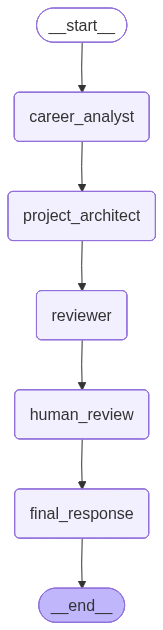

In [32]:
from IPython.display import Image, display
from pathlib import Path

def display_graph(runnable, output_png: Path):
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(filename=str(output_png)))

graph_preview = build_graph()
display_graph(graph_preview, Path("/content/ai_career_project_graph.png"))

## Workflow Execution Order

The graph executes the workflow in a clear sequential order:

1. **Career Analyst Agent** analyzes the user request, target role, skills, and project direction.
2. **Project Architect Agent** creates a concrete project plan based on the career analysis.
3. **Reviewer Agent** checks the project plan against the assignment requirements.
4. **Human-in-the-Loop Review Node** pauses the workflow and asks for human approval or revision feedback.
5. **Final Response Agent** generates the final project recommendation after the human feedback is received.

This execution order confirms that the system is not a single chatbot response, but a structured stateful multi-agent workflow.

## Core Workflow Function

This cell defines the main function used to execute the workflow.

The `execute_workflow` function accepts `user_request` as the main required input.

The optional `human_feedback` parameter is used in the test cases to simulate Human-in-the-Loop approval or revision feedback.

The function initializes the graph, starts execution, handles the interruption, resumes the graph with human feedback, and returns the final result.

In [33]:
def execute_workflow(user_request: str, human_feedback: str = "approve"):
    app = build_graph()

    initial_state = {
        "user_request": user_request,
        "career_analysis": "",
        "project_plan": "",
        "review_feedback": "",
        "human_feedback": "",
        "final_output": "",
        "messages": [HumanMessage(content=user_request)]
    }

    config = {
        "configurable": {
            "thread_id": "career_project_thread"
        }
    }

    result = app.invoke(initial_state, config=config)

    if "__interrupt__" in result:
        print("Human-in-the-Loop interruption triggered.")
        print(result["__interrupt__"])

        result = app.invoke(
            Command(resume=human_feedback),
            config=config
        )

    return result


print("execute_workflow function defined successfully.")

execute_workflow function defined successfully.


## Test Case 1 – Approval Flow

This test demonstrates the full workflow with human approval.

The user asks for a portfolio project recommendation for a Junior AI Automation role.

The workflow executes the following steps:

1. Career Analyst Agent analyzes the user request.
2. Project Architect Agent creates a project plan.
3. Reviewer Agent checks the plan against the assignment requirements.
4. Human-in-the-Loop interruption is triggered.
5. The workflow resumes with human feedback: `approve`.
6. Final Response Agent produces the final approved project recommendation.

This test proves that the workflow supports agent collaboration, memory, Human-in-the-Loop interruption, and final approval.

In [34]:
test_1 = execute_workflow(
    "I want to apply for a Junior AI Automation role. Suggest a portfolio project.",
    human_feedback="approve"
)

print(test_1["final_output"])

Human-in-the-Loop interruption triggered.
[Interrupt(value={'message': "Human review required. Type 'approve' or provide revision feedback.", 'project_plan': '# AI Career Project Strategist\n\n## 1. Project Title\nAI Career Project Strategist\n\n## 2. Problem Solved\nThe project aims to automate the process of selecting, evaluating, and improving AI portfolio projects for users aspiring to enter the AI automation field. It provides a structured approach to career development by leveraging AI technologies to enhance user portfolios and skills.\n\n## 3. LangGraph and LangChain Architecture\nThe architecture consists of a LangGraph StateGraph that includes nodes representing different workflow states and edges that define the transitions between these states. The workflow utilizes LangChain\'s ChatOpenAI for natural language processing and interaction. The StateGraph will manage the flow of information through the following states: user_request, career_analysis, project_plan, review_feedb

## Test Case 2 – Revision Feedback Flow

This test demonstrates the Human-in-the-Loop revision flow.

The user asks for a project that is realistic for a 10-day student assignment.

Instead of approving immediately, the human feedback asks the workflow to make the project more realistic and to emphasize the exact LangGraph workflow, tools, memory, and Human-in-the-Loop step.

The workflow executes the following steps:

1. Career Analyst Agent analyzes the request.
2. Project Architect Agent creates a project plan.
3. Reviewer Agent checks the plan.
4. Human-in-the-Loop interruption is triggered.
5. The workflow resumes with revision feedback.
6. Final Response Agent produces an updated final recommendation.

This test proves that the workflow can continue after human feedback and adjust the final output based on the requested revision.

In [35]:
test_2 = execute_workflow(
    "I want to apply for a Junior AI Automation role, but I need a project that is realistic for 10 days.",
    human_feedback="Please make the project more realistic for a 10-day student assignment and emphasize the exact LangGraph workflow, tools, memory, and Human-in-the-Loop step."
)

print(test_2["final_output"])

Human-in-the-Loop interruption triggered.
[Interrupt(value={'message': "Human review required. Type 'approve' or provide revision feedback.", 'project_plan': '# AI Career Project Strategist\n\n## 1. Project Title\nAI Career Project Strategist\n\n## 2. Problem Solved\nThe project addresses the challenge of guiding users in selecting, evaluating, improving, and finalizing their AI portfolio projects. It automates the career planning process for individuals aiming for roles in AI, particularly in automation, by leveraging existing skills and identifying areas for improvement.\n\n## 3. LangGraph and LangChain Architecture\nThe architecture utilizes LangGraph\'s StateGraph to manage the workflow states effectively. The StateGraph consists of nodes representing different stages of the project, including career analysis, project planning, and review feedback. Edges connect these nodes, facilitating smooth transitions between states. The LangChain ChatOpenAI component is integrated to provide 

## Test Case 3 – Skill Gap Analysis Flow

This test demonstrates how the workflow handles a user who already has some AI-related skills but is not fully confident with LangGraph.

The user explains that they know basic Python, are learning LangChain, and are not confident with LangGraph yet.

The workflow executes the following steps:

1. Career Analyst Agent analyzes the user's current skills and target role.
2. Project Architect Agent creates a realistic project plan.
3. Reviewer Agent checks the plan against the assignment requirements.
4. Human-in-the-Loop interruption is triggered.
5. The workflow resumes with approval.
6. Final Response Agent produces the final recommendation.

This test proves that the workflow can process skill-related user input and generate a project recommendation that supports career development and portfolio building.

In [36]:
test_3 = execute_workflow(
    "I know basic Python and I am learning LangChain, but I am not confident with LangGraph yet. What AI portfolio project should I build?",
    human_feedback="approve"
)

print(test_3["final_output"])

Human-in-the-Loop interruption triggered.
[Interrupt(value={'message': "Human review required. Type 'approve' or provide revision feedback.", 'project_plan': '# Project Plan for "AI Career Project Strategist"\n\n## 1. Project Title\nAI Career Project Strategist\n\n## 2. Problem Solved\nThe project aims to assist users in strategizing their AI career paths, specifically targeting roles in AI automation. It provides tailored recommendations based on existing skills, desired career goals, and project complexity, ultimately enhancing users\' employability in the AI field.\n\n## 3. LangGraph and LangChain Architecture\nThe architecture consists of a LangGraph StateGraph that manages the workflow through various nodes and edges, representing the flow of information and tasks between agents. The ChatOpenAI component facilitates natural language interactions, allowing users to communicate their career aspirations and receive feedback. The StateGraph will track the progress through the defined 

## Test Case 4 – Portfolio Alignment Flow

This test demonstrates how the workflow handles a user who wants to build a portfolio project that looks relevant for job applications.

The user asks for a project that can demonstrate practical AI automation skills to future employers.

The workflow executes the following steps:

1. Career Analyst Agent analyzes the user's career goal and portfolio needs.
2. Project Architect Agent creates a project plan focused on portfolio value.
3. Reviewer Agent checks the project plan against the assignment requirements.
4. Human-in-the-Loop interruption is triggered.
5. The workflow resumes with approval.
6. Final Response Agent produces the final recommendation.

This test proves that the workflow can connect the project idea with career positioning and portfolio presentation.

In [37]:
test_4 = execute_workflow(
    "I want a portfolio project that will look relevant when I apply for Junior AI Automation jobs.",
    human_feedback="approve"
)

print(test_4["final_output"])

Human-in-the-Loop interruption triggered.
[Interrupt(value={'message': "Human review required. Type 'approve' or provide revision feedback.", 'project_plan': '# AI Career Project Strategist\n\n## 1. Project Title\nAI Career Project Strategist\n\n## 2. Problem Solved\nThe project addresses the challenge of effectively selecting, evaluating, and improving AI portfolio projects for individuals aiming to enter the Junior AI Automation field. It automates the process, providing users with a structured approach to align their projects with career goals.\n\n## 3. LangGraph and LangChain Architecture\nThe architecture utilizes LangGraph\'s StateGraph to manage the workflow, consisting of nodes representing different stages of the project and edges that define the transitions between these stages. The ChatOpenAI component is integrated to facilitate natural language interactions throughout the workflow, enhancing user engagement and feedback collection.\n\n## 4. Implemented Agents and Responsib

## Test Case 5 – Assignment Compliance Flow

This test demonstrates how the workflow handles a user request focused on meeting the final assignment requirements.

The user asks whether the project includes the required elements such as LangGraph, LangChain, multiple agents, custom tools, memory, Human-in-the-Loop, and test cases.

The workflow executes the following steps:

1. Career Analyst Agent analyzes the assignment-oriented request.
2. Project Architect Agent creates a project plan aligned with the assignment requirements.
3. Reviewer Agent checks whether the plan satisfies the required components.
4. Human-in-the-Loop interruption is triggered.
5. The workflow resumes with approval.
6. Final Response Agent produces the final recommendation.

This test proves that the workflow can evaluate whether the project is aligned with the final assignment expectations.

In [38]:
test_5 = execute_workflow(
    "I need to make sure my final project includes LangGraph, LangChain, multiple agents, tools, memory, Human-in-the-Loop, and test cases.",
    human_feedback="approve"
)

print(test_5["final_output"])

Human-in-the-Loop interruption triggered.
[Interrupt(value={'message': "Human review required. Type 'approve' or provide revision feedback.", 'project_plan': '# Project Plan for "AI Career Project Strategist"\n\n## 1. Project Title\nAI Career Project Strategist\n\n## 2. Problem Solved\nThe project aims to assist users in navigating their AI career paths by providing tailored project strategies based on their skills and career goals. It automates the process of analyzing user profiles, generating project plans, and offering feedback, thereby streamlining the decision-making process for aspiring AI professionals.\n\n## 3. LangGraph and LangChain Architecture\nThe architecture of the project is built using LangGraph and LangChain, featuring a StateGraph that organizes the workflow into nodes and edges. The nodes represent different stages of the workflow, including career analysis, project planning, and review. ChatOpenAI is integrated to facilitate natural language interactions with user

## Final Testing Summary and Requirement Coverage

The notebook includes five test cases that demonstrate the main functionality of the multi-agent workflow.

### Covered Test Scenarios

1. **Approval Flow**  
   Demonstrates the complete workflow with human approval.

2. **Revision Feedback Flow**  
   Demonstrates that the Human-in-the-Loop step can provide revision feedback before the workflow resumes.

3. **Skill Gap Analysis Flow**  
   Demonstrates that the workflow can process user skill information and generate a relevant career-oriented project recommendation.

4. **Portfolio Alignment Flow**  
   Demonstrates that the workflow can connect the project recommendation with portfolio value and job application goals.

5. **Assignment Compliance Flow**  
   Demonstrates that the workflow can check whether the project includes the required assignment components.

### Assignment Requirements Demonstrated

The tests show that the project includes:

- LangGraph StateGraph workflow
- LangChain ChatOpenAI integration
- Multiple specialized agents
- Custom tools
- Defined WorkflowState
- MemorySaver checkpointer
- Human-in-the-Loop interruption with `interrupt()`
- Resume logic with `Command(resume=...)`
- Core function `execute_workflow(user_request, human_feedback="approve")`
- At least five test cases

These tests confirm that the project satisfies the main technical and functional requirements of the final assignment.